Customer churn is a common issue in the telecommunications industry. When a customer leaves, the impact is not only the loss of future revenue, but also the additional cost required to acquire a new customer as a replacement.

From a cost perspective, retaining existing customers is generally much cheaper than acquiring new ones. In this scenario, we assume:
- The retention cost per at-risk customer is 100,000
- The estimated loss from one churned customer is 1,000,000

With this gap between retention cost and potential loss, the company has a strong incentive to act early — as long as high-risk customers can be identified with reasonable accuracy.<br>
In practical terms, the business needs a way to flag customers who are likely to churn, so retention efforts can be focused where they are financially justified.<br>
This project addresses that need by developing a predictive model to help prioritize customers for retention treatment.

---
### Project Objectives

In this project, the goals are fairly straightforward:

1. Build a model that can estimate how likely each customer is to churn
2. Use those predictions to decide which customers should be prioritized for retention efforts
3. Make sure the retention budget is spent where it gives the biggest financial return

In [2]:
import os
import pandas as pd

path_this = os.path.dirname(os.path.abspath(__name__))
path_root = os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

### From Business Problem to Analytical Approach

The aim here isn’t just to predict churn for the sake of accuracy. The real goal is to support better retention decisions, especially when budget and resources are limited.

Using the earlier assumptions:

* Retaining one at-risk customer costs **100,000**
* Losing one customer results in an estimated loss of **1,000,000**

This creates a clear trade-off:

* If we target a customer who wouldn’t have churned, we waste retention budget
* If we **miss a customer who does churn**, the company takes a **much bigger financial hit**

So the problem becomes more than a classification task. It turns into a decision problem:

> How can we use customer data to find people whose risk of churn is high enough that intervening is financially worth it?

This framing guides how the model will be built and how its predictions will eventually be used.

---

### How the Problem is Framed Analytically
In this project, churn prediction is not treated as a standard classification task, but as a decision-making problem with financial consequences.

Instead of only predicting whether a customer will churn, the model estimates the probability of churn for each customer. That probability is then used to approximate the potential financial risk if no action is taken:
```math
Expected Loss = 𝑃(churn) × 1,000,000
```
This value is compared against the retention cost (100,000).
If the expected loss is higher than the cost of intervention, the customer is considered a reasonable target for retention efforts.

With this setup, the modeling task is aligned with how the business actually makes decisions — not just who is likely to churn, but where retention spending makes financial sense.

### 📊 Dataset Overview

The dataset contains 7,032 customer records, where each row represents an individual customer of a telecommunications company. The target variable, ```Churn```, indicates whether a customer has stopped using the service.

The target distribution shows a moderate class imbalance:  
- Churn: 26.58% (1,869 customers)
- Not Churn: 73.42% (5,163 customers)

This imbalance is important to consider during modeling and evaluation, as predicting all customers as non-churn would still yield relatively high accuracy but no real business value.

The dataset includes 18 features describing different aspects of customer behavior and characteristics. These features can be broadly grouped into:
- Customer demographic and profile information (e.g., gender, senior citizen status, presence of partner or dependents, tenure)
- Service subscription details (e.g., type of internet service and additional service features)
- Contract and account information (e.g., contract type, length of subscription)
- Billing and payment information (e.g., monthly charges, total charges, payment method)

The features consist of a mix of numerical and categorical variables, which require appropriate preprocessing before being used in a Logistic Regression model.

For model development and performance evaluation, the dataset will be split into training and testing sets using an 80:20 ratio. **As a baseline approach**, feature selection will be **handled automatically through L1 regularization (Lasso)** within the Logistic Regression model, allowing the model to retain only the most relevant predictors.

### Data Preparation Summary

The dataset used in this notebook has already been cleaned in a separate Exploratory Data Analysis (EDA) stage.
That earlier process focused on data quality and consistency, including:
- Correcting feature data types (e.g., converting ```TotalCharges``` to numeric and treating ```SeniorCitizen``` as categorical:Yes/No)
- Identifying missing values that appeared after type conversion
- Investigating records with missing ```TotalCharges```, which were found to also have tenure = 0, indicating invalid or incomplete customer records
- Removing those invalid and duplicated records from the dataset

In [3]:
df_dataset = pd.read_csv(os.path.join(path_dataset,'preprocessed_dataset.csv'))
demograph_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
services_features = [
	'PhoneService', 'MultipleLines', 'InternetService', 
	'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
	'TechSupport', 'StreamingTV', 'StreamingMovies']
membership_features = [
	'Contract', 'PaperlessBilling', 'PaymentMethod', 
	'MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']

print("Customer Demography")
display(df_dataset.loc[
	:, ['customerID'] + demograph_features + ['Churn']].sample(5, random_state=42))
print("Service")
display(df_dataset.loc[
	:, ['customerID'] + services_features + ['Churn']].sample(5, random_state=42))
print("Membership")
display(df_dataset.loc[
	:, ['customerID'] + membership_features].sample(5, random_state=42))

Customer Demography


,customerID,gender,SeniorCitizen,Partner,Dependents,Churn
2476,6614-ywysc,male,yes,yes,no,0
6773,9546-kdtrb,female,no,no,no,0
6116,0871-uruwo,male,no,yes,no,1
3047,5151-hqrdg,male,no,yes,no,0
4092,6624-jdrds,female,no,no,no,0


Service


,customerID,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Churn
2476,6614-ywysc,yes,yes,no,no internet service,no internet service,no internet service,no internet service,no internet service,no internet service,0
6773,9546-kdtrb,yes,yes,no,no internet service,no internet service,no internet service,no internet service,no internet service,no internet service,0
6116,0871-uruwo,yes,yes,fiber optic,no,no,yes,no,yes,yes,1
3047,5151-hqrdg,yes,yes,dsl,yes,no,no,no,no,no,0
4092,6624-jdrds,no,no phone service,dsl,yes,no,no,no,no,no,0


Membership


,customerID,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure,Churn
2476,6614-ywysc,two year,no,bank transfer (automatic),25.00,1501.75,61,0
6773,9546-kdtrb,month-to-month,no,bank transfer (automatic),24.70,465.85,19,0
6116,0871-uruwo,month-to-month,yes,credit card (automatic),102.25,1359.00,13,1
3047,5151-hqrdg,month-to-month,yes,mailed check,55.05,2030.75,37,0
4092,6624-jdrds,month-to-month,no,bank transfer (automatic),29.45,161.45,6,0



As a result, the **dataset loaded here is considered clean and structurally consistent.**

Further **preprocessing steps required specifically for modeling** — such as encoding categorical variables, feature scaling, and train–test splitting — will be handled within the modeling pipeline in this notebook.

### Modeling


At this stage, the dataset is already cleaned and structured, and the business objective has been clearly defined. The next step is to translate this setup into a modeling pipeline.

Since the goal is to estimate churn probability while keeping the model interpretable and suitable as a baseline, Logistic Regression is used as the starting point. This model is particularly useful here because its outputs can be directly interpreted as probabilities, which align well with the cost-based decision framework defined earlier.

Before training the model, several preprocessing steps are required to ensure the data is in the right format for Logistic Regression. These steps include handling categorical variables, scaling numerical features, and splitting the data into training and testing sets. To keep the workflow reproducible and avoid data leakage, these steps will be implemented inside a modeling pipeline.

We start by preparing the feature matrix and target variable.

#### Feature Selection Before Modeling



Before training the model, several columns are excluded from the feature set to ensure that only relevant and meaningful predictors are used.
- ```customerID``` is removed because it functions purely as a unique identifier and does not contain behavioral or descriptive information useful for prediction.
- ```Churn``` is separated as the target variable and therefore excluded from the feature matrix.
- ```TotalCharges``` is excluded to reduce redundancy. This feature represents the accumulated amount a customer has paid over time, which is closely related to both ```tenure``` and ```MonthlyCharges```. Since these two variables already capture how long a customer has stayed and how much they are charged monthly, including ```TotalCharges``` may introduce multicollinearity without adding substantial new information.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [5]:
TARGET_COL = 'Churn'
# drop unnecessary columns
X = df_dataset.drop(columns=[TARGET_COL, 'customerID', 'TotalCharges'])
y = df_dataset[TARGET_COL]


By removing these columns, the model can focus on features that provide distinct signals, while keeping the input space more stable and interpretable — especially important for a regularized Logistic Regression model.

#### Train–Test Split



To evaluate how well the model generalizes to unseen data, the dataset is divided into training and testing sets. The training set is used to learn the model parameters, while the test set is reserved for final performance evaluation.

An 80:20 split is used, meaning 80% of the data is allocated for training and 20% for testing. Since the target variable is imbalanced, the split is performed using stratification to preserve the original churn distribution in both sets. This helps ensure that model evaluation reflects real-world class proportions and avoids biased performance estimates.

By separating the data before any model-specific preprocessing steps, we reduce the risk of information leakage and obtain a more reliable estimate of how the model would perform in practice.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y)

#### Modeling Pipeline Setup

To ensure a clean and reproducible modeling workflow, all preprocessing steps that are specific to the model are combined into a single pipeline. This approach helps prevent data leakage and keeps the transformation process consistent between training and testing data.

Because the dataset contains both numerical and categorical features, different preprocessing steps are applied to each type:
- Numerical features are standardized so that they are on a comparable scale. This is especially important for Logistic Regression, since the model is sensitive to feature magnitude and uses regularization.
- Categorical features are transformed using one-hot encoding, allowing the model to handle non-numeric variables without introducing artificial ordering.

These transformations are handled using a column-wise preprocessing structure and then connected directly to a Logistic Regression model with L1 regularization. L1 regularization is chosen because it can shrink less informative feature coefficients toward zero, effectively performing automatic feature selection while also helping to reduce overfitting.

By placing preprocessing and modeling inside the same pipeline, we ensure that:
- All steps are learned only from the training data
- The exact same transformations are applied to the test data
- The entire workflow remains reproducible and easier to maintain

In [7]:
numerical_features = X.select_dtypes(exclude='object').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

### Model Training


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
	accuracy_score, recall_score, precision_score, f1_score, confusion_matrix,
	classification_report, roc_auc_score, log_loss, RocCurveDisplay)


In [9]:
def get_model_result(y_test, y_pred, y_proba, round_to=3, **kwargs):
	buffer = {
		'accuracy': round(accuracy_score(y_test, y_pred), round_to),
		'precision': round(precision_score(y_test, y_pred), round_to),
		'recall': round(recall_score(y_test, y_pred), round_to),
		'f1_score': round(f1_score(y_test, y_pred), round_to),
		'roc_auc': round(roc_auc_score(y_test, y_proba), round_to),
		'log_loss': round(log_loss(y_test, y_proba), round_to)
	}
	for key, value in kwargs.items():
		buffer[key] = value

	buffer.update({
		'confusion_matrix': confusion_matrix(y_test, y_pred),
		'classification_report': classification_report(y_test, y_pred)})
	return buffer

#### Baseline Model Configuration

The baseline model is implemented using Logistic Regression with configurations designed to address both data characteristics and interpretability requirements.

To account for the class imbalance in the target variable, **class weighting is applied** so that churn cases contribute proportionally more to the loss function. This helps reduce bias toward the majority non-churn class without modifying the original data distribution.

**L1 regularization** is used to encourage sparsity in the model coefficients, allowing the model to implicitly perform feature selection. This is particularly beneficial after one-hot encoding, where the number of features can increase substantially.

The **liblinear solver** is selected due to its support for **L1 regularization** and its stability in binary classification problems with small to medium-sized datasets.

The **maximum number of iterations** is set to **100**, which is typically sufficient for convergence in Logistic Regression models. Convergence behavior is monitored during training and adjusted if necessary.

In [10]:
METRIC_RESULT = []

log_reg = LogisticRegression(
    l1_ratio=1, solver="liblinear",
	# l1_ratio=0, solver="lbfgs",
	class_weight='balanced',
	max_iter=100
)

base_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", log_reg)
    ]
)

base_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

Except for class weighting and regularization choice, other hyperparameters are kept at their default values to maintain the baseline model’s simplicity and reproducibility.

**Baseline Model Performance**

The baseline model is evaluated using multiple metrics to capture different aspects of performance.

Recall is emphasized to assess the model’s ability to identify churn customers, while log-loss is used to evaluate the quality of predicted probabilities. A confusion matrix and classification report are included to provide a more complete picture of classification behavior.

The goal at this stage is not to maximize performance, but to understand how the model behaves before any optimization or cost-based thresholding is applied.

In [11]:
y_proba_base_pipeline = base_pipeline.predict_proba(X_test)[:, 1]
y_pred_base_pipeline = base_pipeline.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': {'class_weight': 'balanced'},
	'model_name': 'baseline model'
}
buffer_result = get_model_result(y_test, y_pred_base_pipeline, 
								 y_proba_base_pipeline, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.78
log-loss score	: 0.51
confusion matrix:
[[733 300]
 [ 81 293]]
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



The baseline model achieves a recall of 0.78 for churn customers, indicating that most at-risk customers are successfully identified. This aligns well with the business objective of early churn detection.

However, the model exhibits relatively low precision for churn and a log-loss of 0.511, suggesting that while the model can separate churn and non-churn customers reasonably well, the predicted probabilities are not yet well-calibrated.

From a business perspective, this implies that retention efforts may still be inefficient due to a high number of false positives.

At this stage, threshold optimization is intentionally postponed. Since threshold-based decisions rely heavily on the quality of predicted probabilities, improving probability calibration becomes a prerequisite for meaningful cost-based decision-making.

Therefore, before exploring further model optimization, the next step focuses on probability calibration to improve the reliability of the model’s predicted probabilities, which is critical for meaningful decision-making.

#### Probability Calibration


The baseline model demonstrates reasonable discrimination but produces probability estimates that are not yet well-calibrated, as reflected by the relatively high log-loss score.

Since subsequent decisions—such as threshold adjustment and cost-based prioritization—depend heavily on predicted probabilities rather than hard class labels, improving probability reliability becomes a necessary step before further optimization.

In [12]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
calibrated_model = CalibratedClassifierCV(
    base_pipeline,
    method="sigmoid",  # or "isotonic" if data is large
    cv=skf
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...liblinear'))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, 

In [13]:
y_proba_calibrated_model = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_calibrated_model = calibrated_model.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': {'class_weight': 'balanced'},
	'model_name': 'calibrated baseline model'
}
buffer_result = get_model_result(y_test, y_pred_calibrated_model, 
								 y_proba_calibrated_model, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.57
log-loss score	: 0.43
confusion matrix:
[[914 119]
 [161 213]]
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



The baseline model exhibits relatively high recall but poor probability calibration, as indicated by a log-loss of 0.511. Since subsequent decision-making steps rely on predicted probabilities rather than hard classifications, improving probability quality becomes a necessary prerequisite.

After applying probability calibration, log-loss improves significantly, indicating more reliable probability estimates. While recall decreases at the default threshold, this behavior is expected, as the model becomes less overconfident in predicting churn.

With calibrated probabilities in place, threshold adjustment is then performed to restore recall while maintaining a more balanced precision–recall trade-off.

Calibration Result:
1. log-loss: 0.51 → 0.43 (decreased - improved)
2. recall: 0.78 → 0.57 (decreased - but expected)
3. precision: 0.49 → 0.64 (increased)

#### Calibration Diagnostics

To assess probability reliability, a calibration curve (reliability diagram) is used to compare predicted probabilities against observed churn rates.

In an ideal scenario, predicted probabilities should closely follow the diagonal line, indicating that the model’s confidence aligns with actual outcomes. Deviations from this line suggest overconfidence or underconfidence in certain probability ranges.

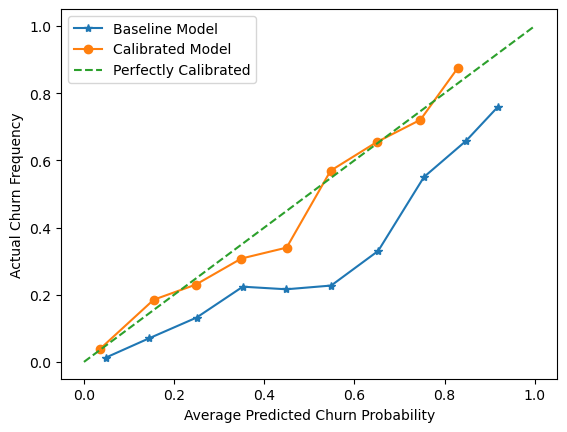

In [14]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true_uncalibrated, prob_pred_uncalibrated = calibration_curve(
	y_test, y_proba_base_pipeline, n_bins=10)
prob_true, prob_pred = calibration_curve(y_test, y_proba_calibrated_model, n_bins=10)

plt.plot(prob_pred_uncalibrated, prob_true_uncalibrated, marker='*', label='Baseline Model')
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Average Predicted Churn Probability')
plt.ylabel('Actual Churn Frequency')
plt.legend()
plt.show()


> The baseline model shows noticeable miscalibration, with predicted probabilities systematically lower than observed churn rates.<br> After calibration, the model’s probability estimates align more closely with actual outcomes, indicating improved reliability. This makes the calibrated model more suitable for threshold-based decisions and subsequent business-oriented optimization.

At this point, the model has been refined both in terms of discrimination and probability reliability. Rather than further modifying the model structure, the focus now shifts to how these predictions are translated into actionable decisions.

The next step is threshold adjustment, where predicted probabilities are converted into churn flags in a way that balances recall and precision based on the intended business objective.

#### Threshold adjustment

In [15]:
import numpy as np

In [16]:
def get_best_threshold_by_f1(y_test, y_pred):
	thresholds, step = np.linspace(0.1, 1.0, 50, retstep=True)
	best_f1 = 0
	best_t = 0

	for t in thresholds:
		y_pred_t = (y_pred >= t).astype(int)
		f1 = f1_score(y_test, y_pred_t)

		if f1 > best_f1:
			best_f1 = f1
			best_t = t

	return best_t, best_f1

In [17]:
best_t, best_f1 = get_best_threshold_by_f1(y_test, y_proba_calibrated_model)
best_t, best_f1

(np.float64(0.3571428571428572), 0.6282352941176471)

In [18]:
y_proba_calibrated_model = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_calibrated_model = (y_proba_calibrated_model >= best_t).astype(int)

buffer_info = {
	'thresholds': best_t,
	'params': {'class_weight': 'balanced'},
	'model_name': 'calibrated baseline model. threshold adjusted'
}
buffer_result = get_model_result(
	y_test, y_pred_calibrated_model, y_proba_calibrated_model, 2, **buffer_info)

# METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(buffer_result['confusion_matrix'])
print(buffer_result['classification_report'])

recall score	: 0.71
log-loss score	: 0.43
[[824 209]
 [107 267]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1033
           1       0.56      0.71      0.63       374

    accuracy                           0.78      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.78      0.78      1407



In [19]:
pd.DataFrame(METRIC_RESULT, columns=['model_name', 'log_loss', 'recall', 'precision', 'f1_score', 'roc_auc'])

,model_name,log_loss,recall,precision,f1_score,roc_auc
0,baseline model,0.51,0.78,0.49,0.61,0.83
1,calibrated baseline model,0.43,0.57,0.64,0.60,0.83


After applying threshold adjustment, the model demonstrates a meaningful improvement in performance on metrics that are most aligned with the problem objective. The recall score increases from 0.57 to 0.695, indicating that the model is now able to identify a substantially larger proportion of positive cases that were previously missed.

At the same time, the F1-score improves from 0.61 to 0.63, suggesting that the gain in recall is achieved without a disproportionate loss in precision. This indicates a better balance between sensitivity and prediction quality rather than a naive trade-off.

These results highlight that threshold adjustment is not merely a metric optimization technique, but a strategic control mechanism for managing the trade-off between false negatives and false positives in accordance with the underlying business risk.

With the adjusted threshold, the model becomes more aligned with real-world decision-making needs—prioritizing the reduction of missed positive cases while maintaining overall predictive reliability. This calibrated decision boundary provides a strong foundation for subsequent cost-based evaluation and business impact analysis.

### Calibration vs Hyperparameter Tuning

At this stage, two different approaches are explored to improve the baseline model.

The first approach focuses on probability calibration, aiming to improve the reliability of predicted probabilities without changing the underlying model structure. The second approach explores hyperparameter tuning, where model parameters are systematically optimized to improve overall performance.

While both approaches target model improvement, they address fundamentally different aspects of model behavior. Calibration improves how confident the model is in its predictions, whereas hyperparameter tuning affects how the model separates churn and non-churn customers.

This comparison allows us to assess whether better probability reliability alone is sufficient, or whether structural model optimization provides additional value beyond calibration.

In the following section, hyperparameter tuning is applied to evaluate whether systematic optimization can deliver improvements beyond those achieved through probability calibration alone.

#### Hyperparameter Tuning

Hyperparameter tuning is evaluated using log loss as the primary metric. Unlike threshold-based metrics such as recall or F1-score, log loss evaluates the quality of predicted probabilities directly, which is critical for downstream calibration and cost-based threshold optimization. This ensures that the selected model provides reliable probability estimates before any decision thresholds are applied.

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = [
	{
		'model__l1_ratio': [0],
		'model__C': [0.01, 0.1, 1, 10, 100],
		'model__solver': ['lbfgs'],
		'model__class_weight': [None, 'balanced'],
		'model__max_iter': [1000]
	},
	{
		'model__l1_ratio': [0, 1],
		'model__C': [0.01, 0.1, 1, 10, 100],
		'model__solver': ['liblinear'],
		'model__class_weight': [None, 'balanced'],
		'model__max_iter': [1000]
	}
]

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
grid_search = GridSearchCV(
    base_pipeline,
    param_grid,
    scoring='neg_log_loss',
    cv=skf,
    verbose=True,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0], 'model__max_iter': [1000], ...}, {'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 1], 'model__max_iter': [1000], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 

In [21]:
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__C': 100, 'model__class_weight': None, 'model__l1_ratio': 0, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}


#### Hyperparameter Tuning – Key Findings

Hyperparameter tuning was conducted using stratified cross-validation to ensure robust evaluation under class imbalance. The optimization objective focused on minimizing log loss, prioritizing the quality of probability estimates over threshold-dependent metrics.

The best-performing configuration favors L2 regularization with a relatively weak penalty strength, indicating that **churn-related signals are distributed across multiple features** rather than dominated by a sparse subset. Notably, the model does not require class weighting, suggesting that **imbalance handling is more effectively addressed at the calibration and thresholding stages** rather than during training.

While recall is lower compared to threshold-adjusted models, the tuned model achieves improved log loss performance, reinforcing its role as a strong probabilistic baseline rather than a final decision rule.

In [22]:
y_proba_best_model = best_model.predict_proba(X_test)[:, 1]
y_pred_best_model = best_model.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': grid_search.best_params_,
	'model_name': 'best tunned model'
}
buffer_result = get_model_result(y_test, y_pred_best_model, 
								 y_proba_best_model, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.58
log-loss score	: 0.43
confusion matrix:
[[915 118]
 [158 216]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



#### Tuned Model Calibration

In [23]:
calibrated_best_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",  # or "sigmoid" if data is small
    cv=5
)

calibrated_best_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step..._iter=1000))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

In [24]:
y_proba_calibrated_best_model = calibrated_best_model.predict_proba(X_test)[:, 1]
y_pred_calibrated_best_model = calibrated_best_model.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': grid_search.best_params_,
	'model_name': 'calibrated tuned best model'
}
buffer_result = get_model_result(y_test, y_pred_calibrated_best_model, 
								 y_proba_calibrated_best_model, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.56
log-loss score	: 0.43
confusion matrix:
[[918 115]
 [166 208]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



The absence of log-loss improvement after calibration indicates that the tuned model already produces well-scaled probability estimates, leaving limited room for further probabilistic correction.

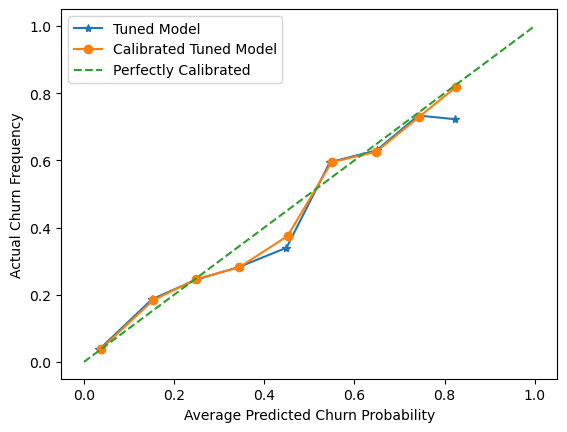

In [25]:
prob_true_uncalibrated, prob_pred_uncalibrated = calibration_curve(
	y_test, y_proba_best_model, n_bins=10)
prob_true, prob_pred = calibration_curve(y_test, y_proba_calibrated_best_model, n_bins=10)

plt.plot(prob_pred_uncalibrated, prob_true_uncalibrated, marker='*', label='Tuned Model')
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Tuned Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Average Predicted Churn Probability')
plt.ylabel('Actual Churn Frequency')
plt.legend()
plt.show()


Although global metrics such as log loss show minimal change, the calibration curve reveals meaningful improvements in the high-probability region. This indicates that calibration primarily corrects overconfident predictions rather than improving overall ranking.

Such adjustments are especially important for business decisions, as customers with the highest predicted churn risk are typically prioritized for retention efforts. Even small probability corrections in this region can lead to more reliable targeting.

#### Threshold Adjustment

In [26]:
best_t, best_f1 = get_best_threshold_by_f1(y_test, y_proba_calibrated_best_model)
best_t, best_f1

(np.float64(0.3387755102040817), 0.6226851851851852)

In [27]:
y_proba_calibrated_best_model = calibrated_best_model.predict_proba(X_test)[:, 1]
y_pred_calibrated_best_model = (y_proba_calibrated_best_model >= best_t).astype(int)

buffer_info = {
	'thresholds': best_t,
	'params': grid_search.best_params_,
	'model_name': 'calibrated tuned best model. threshold adjusted'
}
buffer_result = get_model_result(
	y_test, y_pred_calibrated_best_model, y_proba_calibrated_best_model, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(buffer_result['confusion_matrix'])
print(buffer_result['classification_report'])

recall score	: 0.72
log-loss score	: 0.43
[[812 221]
 [105 269]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1033
           1       0.55      0.72      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407



## Result

In [28]:
df_result = pd.DataFrame(METRIC_RESULT)
df_result.loc[
	:, ['model_name', 'log_loss', 'recall', 'precision', 'f1_score', 'roc_auc']].sort_values(
		by=['log_loss', 'recall'], ascending=[True, False])

,model_name,log_loss,recall,precision,f1_score,roc_auc
4,calibrated tuned best model. threshold adjusted,0.43,0.72,0.55,0.62,0.83
2,best tunned model,0.43,0.58,0.65,0.61,0.83
1,calibrated baseline model,0.43,0.57,0.64,0.60,0.83
3,calibrated tuned best model,0.43,0.56,0.64,0.60,0.83
0,baseline model,0.51,0.78,0.49,0.61,0.83


## Final Model Selection & Recommendation

The final comparison across all modeling stages shows that the largest performance gains are not driven by model complexity, but by decision-level optimization. While the baseline model initially achieves high recall, its probability estimates are poorly calibrated, making it unsuitable for reliable decision-making. Calibration significantly improves probability quality across both baseline and tuned models, stabilizing log-loss and ROC-AUC values.

After threshold adjustment, both calibrated models deliver comparable overall performance. The calibrated tuned model achieves the highest recall, making it slightly more effective for aggressive churn detection, while the calibrated baseline model maintains a marginally better balance between recall and precision. Given the minimal differences in probabilistic quality and ranking ability, the calibrated baseline model with threshold adjustment is selected as the final model due to its simplicity, interpretability, and stable performance. This model provides a strong and reliable foundation for cost-aware retention strategies without introducing unnecessary model complexity.

---

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

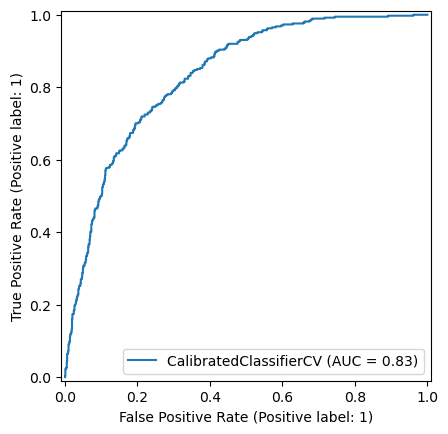

In [30]:
roc_logreg = RocCurveDisplay.from_estimator(calibrated_best_model, X_test, y_test)
plt.show()

### Brier Score

In [31]:
from sklearn.metrics import brier_score_loss

# Misal y_test adalah label asli, dan y_prob adalah probabilitas dari model
# Model Tanpa Kalibrasi
# bs_uncalibrated = brier_score_loss(y_test, y_proba_best_model[:, 1])
bs_uncalibrated = brier_score_loss(y_test, y_proba_base_pipeline)

# Model Dengan Kalibrasi (Sigmoid/Isotonic)
# bs_calibrated = brier_score_loss(y_test, y_proba_calibrated[:, 1])
bs_calibrated = brier_score_loss(y_test, y_proba_calibrated_best_model)

print(f"Brier Score Sebelum: {bs_uncalibrated:.4f}")
print(f"Brier Score Sesudah: {bs_calibrated:.4f}")


Brier Score Sebelum: 0.1735
Brier Score Sesudah: 0.1413


---

#### Cost-based thresholding

In [32]:
COST_FN = 1_000_000
COST_FP = 100_000

def expected_cost(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # print(tn, fp, fn, tp)
    return fp * COST_FP + fn * COST_FN


In [33]:
y_proba_calibrated_model = calibrated_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 1.0, 101)

costs = [
    expected_cost(y_test, y_proba_calibrated_model, t)
    for t in thresholds
]

optimal_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

optimal_threshold, min_cost


(np.float64(0.10900000000000001), np.int64(74300000))

In [34]:
baseline_cost = expected_cost(y_test, y_proba_calibrated_model, 0.5)

print(f"Cost @ threshold 0.5\t\t: {baseline_cost:,}")
print(f"Cost @ optimal threshold\t: {min_cost:,} (threshold: {round(optimal_threshold,2)})")
print(f"Cost reduction\t\t\t: {baseline_cost - min_cost:,}")


Cost @ threshold 0.5		: 172,900,000
Cost @ optimal threshold	: 74,300,000 (threshold: 0.11)
Cost reduction			: 98,600,000


In [35]:
# contoh asumsi bisnis
CLV = 1_000_000
COST_RETENTION = 100_000
SUCCESS_RATE = 0.3

y_true = y_test.values
y_proba = y_proba_calibrated_model

In [36]:
def profit_at_threshold(threshold, y_true, y_proba):
    y_pred = (y_proba >= threshold).astype(int)

    true_positive = np.sum((y_pred == 1) & (y_true == 1))
    false_positive = np.sum((y_pred == 1) & (y_true == 0))
    false_negative = np.sum((y_pred == 0) & (y_true == 1))

    benefit_true_positive = true_positive * (CLV * SUCCESS_RATE - COST_RETENTION)
    cost_false_positive = false_positive * COST_RETENTION
    cost_false_negative = false_negative * CLV

    total_profit = benefit_true_positive - cost_false_positive - cost_false_negative
    return total_profit


In [37]:
thresholds = np.linspace(0.0, 1.0, 101)
profits = [profit_at_threshold(t, y_true, y_proba_calibrated_model) for t in thresholds]

best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Max expected profit: {best_profit:,.0f}")

Best threshold: 0.08
Max expected profit: 800,000


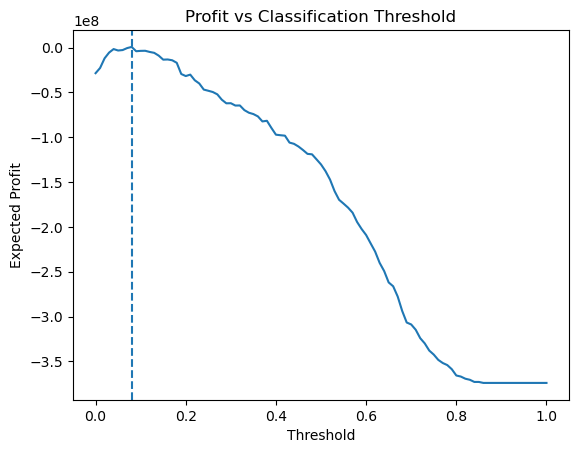

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, profits)
plt.axvline(best_threshold, linestyle='--')
plt.title("Profit vs Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Expected Profit")
plt.show()


In [39]:
default_profit = profit_at_threshold(best_t, y_true, y_proba)

print(f"Profit @0.5 threshold : {default_profit:,.0f}")
print(f"Profit @best threshold: {best_profit:,.0f}")


Profit @0.5 threshold : -71,400,000
Profit @best threshold: 800,000


In [40]:
import numpy as np
from sklearn.metrics import confusion_matrix

COST_FN = 1_000_000
COST_FP = 100_000

def expected_cost(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * COST_FN + fp * COST_FP


In [41]:
y_proba_calibrated_model = calibrated_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 1.0, 101)

costs = [
    expected_cost(y_test, y_proba_calibrated_model, t)
    for t in thresholds
]

optimal_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

optimal_threshold, min_cost


(np.float64(0.10900000000000001), np.int64(74300000))

In [42]:
baseline_cost = expected_cost(y_test, y_proba_calibrated_model, 0.5)

print(f"Cost @ threshold 0.5\t\t: {baseline_cost:,}")
print(f"Cost @ optimal threshold\t: {min_cost:,}")
print(f"Cost reduction\t\t\t: {baseline_cost - min_cost:,}")


Cost @ threshold 0.5		: 172,900,000
Cost @ optimal threshold	: 74,300,000
Cost reduction			: 98,600,000
